In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os

# Create data directory if it doesn't exist
os.makedirs('data', exist_ok=True)

In [ ]:
# Download 3-month Treasury bill data and convert to monthly compound returns
# Load from saved data if exists, otherwise download and save
if os.path.exists('data/tbill_monthly.csv'):
    print("Loading Treasury bill data from saved file...")
    tbill_monthly = pd.read_csv('data/tbill_monthly.csv', index_col=0, parse_dates=True).squeeze()
else:
    print("Downloading Treasury bill data from yfinance...")
    tbill_annual = yf.download("^IRX", start="2013-12-31", end="2023-12-31").resample('ME').last()['Close'] / 100
    tbill_monthly = (1 + tbill_annual)**(1/12) - 1  # Convert annual rate to monthly compound rate
    tbill_monthly = tbill_monthly.iloc[1:]  # Align with etf_returns (drop first price, keep returns)
    # Save for future use
    tbill_monthly.to_csv('data/tbill_monthly.csv')
    print("Treasury bill data saved to data/tbill_monthly.csv")

[*********************100%***********************]  1 of 1 completed


In [ ]:
# Download ETF data and convert to monthly returns (auto_adjust=True accounts for dividends)
# Load from saved data if exists, otherwise download and save
if os.path.exists('data/etf_returns.csv'):
    print("Loading ETF returns data from saved file...")
    etf_returns = pd.read_csv('data/etf_returns.csv', index_col=0, parse_dates=True)
else:
    print("Downloading ETF data from yfinance...")
    etf_returns = (yf.download(["SPY", "EEM", "FM"], start="2013-12-31", end="2023-12-31", auto_adjust=True)
                   .xs("Close", level="Price", axis=1)
                   .resample("ME").last()
                   .pct_change()
                   .dropna())
    # Save for future use
    etf_returns.to_csv('data/etf_returns.csv')
    print("ETF returns data saved to data/etf_returns.csv")


[*********************100%***********************]  3 of 3 completed


In [6]:
# Print shapes for all dataframes/series
print("tbill_monthly shape:", tbill_monthly.shape)
print("etf_returns shape:", etf_returns.shape)


tbill_monthly shape: (120, 1)
etf_returns shape: (120, 3)


In [7]:
print("tbill_monthly head:", tbill_monthly.head())
print("etf_returns head:", etf_returns.head())

tbill_monthly head: Ticker          ^IRX
Date                
2014-01-31  0.000008
2014-02-28  0.000036
2014-03-31  0.000023
2014-04-30  0.000017
2014-05-31  0.000025
etf_returns head: Ticker           EEM        FM       SPY
Date                                    
2014-01-31 -0.086364  0.001778 -0.035248
2014-02-28  0.033779  0.033432  0.045516
2014-03-31  0.038754  0.037790  0.008295
2014-04-30  0.007803  0.025655  0.006952
2014-05-31  0.029519  0.045992  0.023206


In [ ]:
# Align risk-free rate to ETF return dates
tbill_aligned = (
    tbill_monthly
    .squeeze()
    .reindex(etf_returns.index)
    .ffill()
)

# Compute excess returns
excess_returns = etf_returns.sub(tbill_aligned, axis=0)

# Save excess returns for reproducibility
excess_returns.to_csv('data/excess_returns.csv')

# Annualization factor
ann_factor = 12

# Mean and volatility
mean_annual = etf_returns.mean(axis=0) * ann_factor
vol_annual = etf_returns.std(axis=0) * np.sqrt(ann_factor)

# Excess return mean
mean_excess_annual = excess_returns.mean(axis=0) * ann_factor

# Sharpe ratio: use excess return volatility (not total return volatility)
excess_vol_annual = excess_returns.std(axis=0) * np.sqrt(ann_factor)
sharpe = mean_excess_annual / excess_vol_annual

# Sortino ratio: downside deviation only includes negative excess returns
downside_dev = (
    excess_returns[excess_returns < 0]
    .std(axis=0) * np.sqrt(ann_factor)
)
sortino = mean_excess_annual / downside_dev




In [9]:
# ETF descriptions
descriptions = {"SPY": "(US large cap)", "EEM": "(emerging)", "FM": "(frontier)"}

# Results table
results_table = pd.DataFrame({
    "Description": [descriptions[etf] for etf in mean_annual.index],
    "Mean Annualized Return": mean_annual,
    "Annualized Volatility": vol_annual,
    "Sharpe Ratio": sharpe,
    "Sortino Ratio": sortino
}).round(4)

print("Risk-Adjusted Return Metrics")
print("=" * 60)
print(results_table)

Risk-Adjusted Return Metrics
           Description  Mean Annualized Return  Annualized Volatility  \
Ticker                                                                  
EEM         (emerging)                  0.0333                 0.1751   
FM          (frontier)                  0.0266                 0.1670   
SPY     (US large cap)                  0.1246                 0.1516   

        Sharpe Ratio  Sortino Ratio  
Ticker                               
EEM           0.1184         0.1947  
FM            0.0838         0.1119  
SPY           0.7388         1.0688  


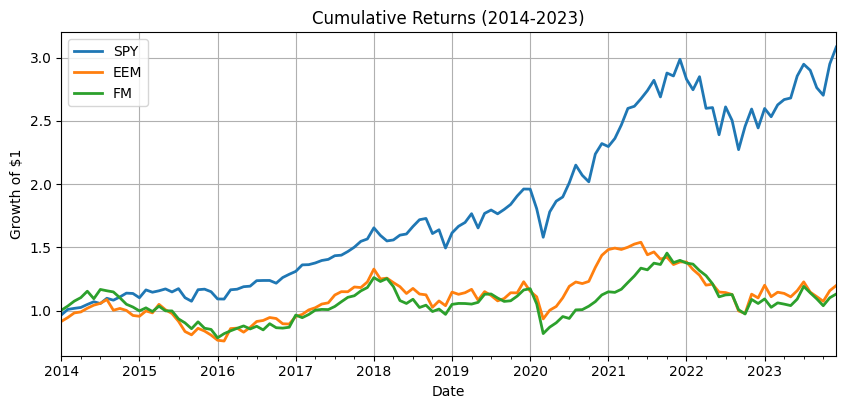

In [10]:
plt.figure(figsize=(10, 4.2))
(1 + etf_returns['SPY']).cumprod().plot(label='SPY', linewidth=2)
(1 + etf_returns['EEM']).cumprod().plot(label='EEM', linewidth=2)
(1 + etf_returns['FM']).cumprod().plot(label='FM', linewidth=2)
plt.legend()
plt.title('Cumulative Returns (2014-2023)')
plt.ylabel('Growth of $1')
plt.grid(True)
plt.show()


In [11]:
print("Correlations with SPY:")
print(f"SPY vs EEM: {etf_returns['SPY'].corr(etf_returns['EEM']):.2}")
print(f"SPY vs FM: {etf_returns['SPY'].corr(etf_returns['FM']):.2}")

Correlations with SPY:
SPY vs EEM: 0.7
SPY vs FM: 0.61


In [12]:
#Calculate downside beta of SPY vs EEM
spy_down_mask = etf_returns['SPY'] < 0
downside_beta_eem = (
    etf_returns.loc[spy_down_mask, ['SPY', 'EEM']].cov().iloc[0, 1] / 
    etf_returns.loc[spy_down_mask, 'SPY'].var()
)
print(f"Downside Beta SPY vs EEM: {downside_beta_eem:.2}")

#Calculate downside beta of SPY vs FM
downside_beta_fm = (
    etf_returns.loc[spy_down_mask, ['SPY', 'FM']].cov().iloc[0, 1] / 
    etf_returns.loc[spy_down_mask, 'SPY'].var()
)
print(f"Downside Beta SPY vs FM: {downside_beta_fm:.2}")




Downside Beta SPY vs EEM: 0.7
Downside Beta SPY vs FM: 1.1


In [13]:
worst_spy_months = etf_returns.nsmallest(10, 'SPY')

spy_cvar = worst_spy_months['SPY'].mean()
eem_cvar = worst_spy_months['EEM'].mean()
fm_cvar = worst_spy_months['FM'].mean()

print(f"\nConditional VaR (10 worst SPY months):")
print(f"SPY average: {spy_cvar:.2%}")
print(f"EEM average: {eem_cvar:.2%}")
print(f"FM average: {fm_cvar:.2%}")
print(f"EEM/SPY ratio: {eem_cvar/spy_cvar:.2f}x")
print(f"FM/SPY ratio: {fm_cvar/spy_cvar:.2f}x")




Conditional VaR (10 worst SPY months):
SPY average: -8.06%
EEM average: -7.34%
FM average: -6.88%
EEM/SPY ratio: 0.91x
FM/SPY ratio: 0.85x
